# Pairwise logistic regression draft model

This notebook trains `PairInteractionDraftModel`: a logistic regression over Dota drafts with independent coefficients for individual heroes, allied synergy pairs, and directed counter-pick pairs.

Target convention: `0` = Radiant won, `1` = Dire won. The model returns Dire-win logits, so `sigmoid(logit)` is `P(Dire win)`.


In [26]:
import copy
import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

import scripts.ml.dataset as dataset_module
import scripts.ml.models.pair_interaction as pair_interaction_module

importlib.reload(dataset_module)
importlib.reload(pair_interaction_module)

DatasetMaker = dataset_module.DatasetMaker
PairInteractionDraftModel = pair_interaction_module.PairInteractionDraftModel


## Configuration

Set each source limit to `None` to use all rows, `0` to skip it, or an integer to cap it.


In [27]:
DOTABUFF_LIMIT = None
OPENDOTA_LIMIT = None
SYNTHETIC_LIMIT = 0
PROFESSIONAL_ONLY = False

VAL_FRACTION = 0.2
BATCH_SIZE = 256
SEED = 42

LR = 3e-3
WEIGHT_DECAY = 1e-3
EPOCHS = 80
PATIENCE = 8
MIN_DELTA = 1e-4
THRESHOLD = 0.5

TOP_N = 25

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## Load Training Drafts

The dataset helper reads database credentials from `.env`, normalizes hero names to numeric ids, and keeps complete 5v5 drafts with known winners.


In [28]:
with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
    drafts = dataset.fetch_normalized_training_match_drafts(
        dotabuff_limit=DOTABUFF_LIMIT,
        opendota_limit=OPENDOTA_LIMIT,
        synthetic_limit=SYNTHETIC_LIMIT,
    )

complete_drafts = [
    draft
    for draft in drafts
    if draft.winner_side is not None
    and len(draft.radiant_hero_ids) == 5
    and len(draft.dire_hero_ids) == 5
]

if PROFESSIONAL_ONLY:
    complete_drafts = [draft for draft in complete_drafts if draft.is_professional_match]

if not complete_drafts:
    raise ValueError("No complete labeled drafts found. Check .env database settings and imported match data.")

pd.DataFrame(
    {
        "matches": [len(complete_drafts)],
        "radiant_wins": [sum(draft.winner_side == 0 for draft in complete_drafts)],
        "dire_wins": [sum(draft.winner_side == 1 for draft in complete_drafts)],
        "professional_known": [sum(draft.is_professional_match is not None for draft in complete_drafts)],
        "professional_true": [sum(draft.is_professional_match is True for draft in complete_drafts)],
    }
)


,matches,radiant_wins,dire_wins,professional_known,professional_true
0,9728,5106,4622,9728,4901


In [29]:
heroes_path = PROJECT_ROOT / "dotaconstants" / "build" / "heroes.json"
heroes = json.loads(heroes_path.read_text(encoding="utf-8"))
num_heroes = max(int(hero["id"]) for hero in heroes.values()) + 1
hero_id_to_name = {
    int(hero["id"]): hero.get("localized_name") or hero["name"].removeprefix("npc_dota_hero_")
    for hero in heroes.values()
}
hero_ids = sorted(hero_id_to_name)

match_ids = torch.tensor([draft.match_id for draft in complete_drafts], dtype=torch.long)
radiant_ids = torch.tensor([draft.radiant_hero_ids for draft in complete_drafts], dtype=torch.long)
dire_ids = torch.tensor([draft.dire_hero_ids for draft in complete_drafts], dtype=torch.long)
labels = torch.tensor([draft.winner_side for draft in complete_drafts], dtype=torch.float32)

indices = np.arange(len(complete_drafts))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

val_size = max(1, int(len(indices) * VAL_FRACTION))
val_idx = torch.tensor(indices[:val_size], dtype=torch.long)
train_idx = torch.tensor(indices[val_size:], dtype=torch.long)

train_ds = TensorDataset(match_ids[train_idx], radiant_ids[train_idx], dire_ids[train_idx], labels[train_idx])
val_ds = TensorDataset(match_ids[val_idx], radiant_ids[val_idx], dire_ids[val_idx], labels[val_idx])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

pd.DataFrame(
    {
        "split": ["train", "validation"],
        "matches": [len(train_ds), len(val_ds)],
        "dire_win_rate": [labels[train_idx].mean().item(), labels[val_idx].mean().item()],
    }
)


,split,matches,dire_win_rate
0,train,7783,0.472311
1,validation,1945,0.486375


## Initialize Model

The model score is:

`bias + Dire heroes - Radiant heroes + Dire synergies - Radiant synergies + Dire counters into Radiant - Radiant counters into Dire`.


In [30]:
train_labels = labels[train_idx]
positive_count = train_labels.sum().item()
negative_count = train_labels.numel() - positive_count
pos_weight = torch.tensor([negative_count / max(positive_count, 1.0)], dtype=torch.float32, device=device)

model = PairInteractionDraftModel(num_heroes=num_heroes).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

pd.DataFrame(
    {
        "num_heroes": [num_heroes],
        "known_heroes": [len(hero_ids)],
        "parameters": [sum(p.numel() for p in model.parameters())],
        "pos_weight": [pos_weight.item()],
    }
)


,num_heroes,known_heroes,parameters,pos_weight
0,156,127,48829,1.117247


## Training Helpers


In [31]:
def binary_metrics_from_counts(tp, tn, fp, fn):
    total = tp + tn + fp + fn
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {
        "accuracy": (tp + tn) / total if total else 0.0,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for _, radiant_batch, dire_batch, label_batch in loader:
        radiant_batch = radiant_batch.to(device)
        dire_batch = dire_batch.to(device)
        label_batch = label_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(radiant_batch, dire_batch)
        loss = criterion(logits, label_batch)
        loss.backward()
        optimizer.step()

        batch_size = label_batch.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples


@torch.no_grad()
def evaluate(model, loader, criterion, device, *, threshold=0.5):
    model.eval()
    total_loss = 0.0
    total_examples = 0
    tp = tn = fp = fn = 0

    for _, radiant_batch, dire_batch, label_batch in loader:
        radiant_batch = radiant_batch.to(device)
        dire_batch = dire_batch.to(device)
        label_batch = label_batch.to(device)

        logits = model(radiant_batch, dire_batch)
        loss = criterion(logits, label_batch)
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= threshold).float()

        batch_size = label_batch.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

        tp += int(((predictions == 1) & (label_batch == 1)).sum().item())
        tn += int(((predictions == 0) & (label_batch == 0)).sum().item())
        fp += int(((predictions == 1) & (label_batch == 0)).sum().item())
        fn += int(((predictions == 0) & (label_batch == 1)).sum().item())

    metrics = binary_metrics_from_counts(tp, tn, fp, fn)
    metrics.update({"loss": total_loss / total_examples, "tp": tp, "tn": tn, "fp": fp, "fn": fn})
    return metrics


## Train


In [32]:
history = []
best_val_loss = float("inf")
best_state = None
best_epoch = 0
stale_epochs = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_metrics = evaluate(model, train_loader, criterion, device, threshold=THRESHOLD)
    val_metrics = evaluate(model, val_loader, criterion, device, threshold=THRESHOLD)
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        **{f"train_{key}": value for key, value in train_metrics.items()},
        **{f"val_{key}": value for key, value in val_metrics.items()},
    }
    history.append(row)

    print(
        f"epoch={epoch:02d} "
        f"train_loss={train_loss:.4f} "
        f"train_accuracy={train_metrics['accuracy']:.3f} "
        f"train_f1={train_metrics['f1']:.3f} "
        f"val_loss={val_metrics['loss']:.4f} "
        f"val_accuracy={val_metrics['accuracy']:.3f} "
        f"val_precision={val_metrics['precision']:.3f} "
        f"val_recall={val_metrics['recall']:.3f} "
        f"val_f1={val_metrics['f1']:.3f}"
    )

    if val_metrics["loss"] < best_val_loss - MIN_DELTA:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        stale_epochs = 0
    else:
        stale_epochs += 1
        if stale_epochs >= PATIENCE:
            print(f"Early stopping at epoch={epoch}; best_epoch={best_epoch}, best_val_loss={best_val_loss:.4f}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df.tail()


epoch=01 train_loss=0.7300 train_accuracy=0.788 train_f1=0.780 val_loss=0.7334 val_accuracy=0.535 val_precision=0.522 val_recall=0.523 val_f1=0.523
epoch=02 train_loss=0.6112 train_accuracy=0.855 train_f1=0.849 val_loss=0.7407 val_accuracy=0.530 val_precision=0.517 val_recall=0.522 val_f1=0.519
epoch=03 train_loss=0.5420 train_accuracy=0.893 train_f1=0.889 val_loss=0.7518 val_accuracy=0.524 val_precision=0.511 val_recall=0.511 val_f1=0.511
epoch=04 train_loss=0.4879 train_accuracy=0.916 train_f1=0.912 val_loss=0.7646 val_accuracy=0.529 val_precision=0.515 val_recall=0.520 val_f1=0.518
epoch=05 train_loss=0.4435 train_accuracy=0.932 train_f1=0.929 val_loss=0.7777 val_accuracy=0.536 val_precision=0.523 val_recall=0.521 val_f1=0.522
epoch=06 train_loss=0.4073 train_accuracy=0.943 train_f1=0.940 val_loss=0.7936 val_accuracy=0.531 val_precision=0.518 val_recall=0.514 val_f1=0.516
epoch=07 train_loss=0.3757 train_accuracy=0.952 train_f1=0.950 val_loss=0.8092 val_accuracy=0.529 val_precision=

,epoch,train_loss,train_accuracy,train_precision,train_recall,train_f1,train_tp,train_tn,train_fp,train_fn,val_accuracy,val_precision,val_recall,val_f1,val_loss,val_tp,val_tn,val_fp,val_fn
4,5,0.405727,0.932417,0.920898,0.937432,0.929091,3446,3811,296,230,0.535733,0.522800,0.521142,0.521969,0.777743,493,549,450,453
5,6,0.373649,0.942696,0.933673,0.945865,0.939730,3477,3860,247,199,0.530591,0.517572,0.513742,0.515650,0.793584,486,546,453,460
6,7,0.346005,0.952204,0.944325,0.955114,0.949689,3511,3900,207,165,0.529049,0.515957,0.512685,0.514316,0.809196,485,544,455,461
7,8,0.321722,0.959399,0.951613,0.963003,0.957274,3540,3927,180,136,0.526478,0.513312,0.509514,0.511406,0.825149,482,542,457,464
8,9,0.300230,0.967879,0.962473,0.969804,0.966125,3565,3968,139,111,0.526992,0.513859,0.509514,0.511677,0.839765,482,543,456,464


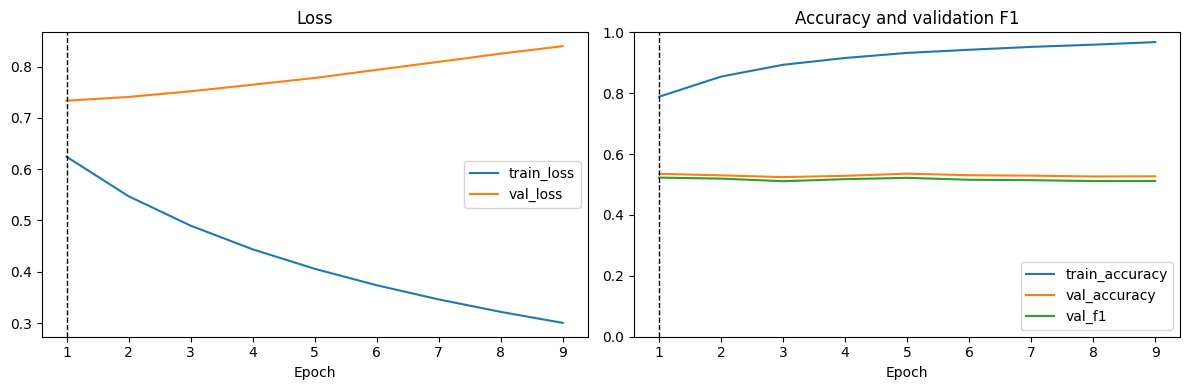

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df.plot(x="epoch", y=["train_loss", "val_loss"], ax=axes[0])
axes[0].axvline(best_epoch, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")

history_df.plot(x="epoch", y=["train_accuracy", "val_accuracy", "val_f1"], ax=axes[1])
axes[1].axvline(best_epoch, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Accuracy and validation F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)

plt.tight_layout()


## Validation Report


In [34]:
final_metrics = evaluate(model, val_loader, criterion, device, threshold=THRESHOLD)
val_labels = labels[val_idx]

report_df = pd.DataFrame(
    [
        {"model": "always_radiant", "accuracy": (val_labels == 0).float().mean().item(), "f1": 0.0, "loss": np.nan},
        {"model": "always_dire", "accuracy": (val_labels == 1).float().mean().item(), "f1": binary_metrics_from_counts(int((val_labels == 1).sum()), 0, int((val_labels == 0).sum()), 0)["f1"], "loss": np.nan},
        {"model": "pair_interaction", "accuracy": final_metrics["accuracy"], "f1": final_metrics["f1"], "loss": final_metrics["loss"]},
    ]
)
report_df


,model,accuracy,f1,loss
0,always_radiant,0.513625,0.000000,NaN
1,always_dire,0.486375,0.654445,NaN
2,pair_interaction,0.535219,0.522703,0.73341


In [35]:
pd.DataFrame(
    [[final_metrics["tn"], final_metrics["fp"]], [final_metrics["fn"], final_metrics["tp"]]],
    index=["actual_radiant", "actual_dire"],
    columns=["predicted_radiant", "predicted_dire"],
)


,predicted_radiant,predicted_dire
actual_radiant,546,453
actual_dire,451,495


# Learned Coefficients

The next cells are the main analysis path. Positive coefficients favor the side that owns the term. Negative coefficients hurt that side.


In [36]:
with torch.no_grad():
    hero_strength = model.hero_strength.weight.detach().cpu().squeeze(-1)
    synergy_weight = model.synergy.detach().cpu()
    counter_weight = model.counter.detach().cpu()


## Individual Heroes

`strength_for_side` is the direct coefficient for placing that hero on a side. A large positive value means the hero pushes the logit toward the side that drafted it.


In [37]:
hero_strength_df = pd.DataFrame(
    [
        {
            "hero_id": hero_id,
            "hero": hero_id_to_name[hero_id],
            "strength_for_side": hero_strength[hero_id].item(),
        }
        for hero_id in hero_ids
    ]
).sort_values("strength_for_side", ascending=False)

hero_strength_df.head(TOP_N)


,hero_id,hero,strength_for_side
87,89,Naga Siren,0.044697
81,83,Treant Protector,0.042990
31,33,Enigma,0.037925
2,3,Bane,0.035712
34,36,Necrophos,0.031375
80,82,Meepo,0.028317
95,97,Magnus,0.026171
65,67,Spectre,0.026080
40,42,Wraith King,0.025664
3,4,Bloodseeker,0.025219


In [38]:
hero_strength_df.tail(TOP_N).sort_values("strength_for_side")


,hero_id,hero,strength_for_side
62,64,Jakiro,-0.043348
36,38,Beastmaster,-0.037836
37,39,Queen of Pain,-0.035001
46,48,Luna,-0.034932
66,68,Ancient Apparition,-0.033729
74,76,Outworld Devourer,-0.033502
0,1,Anti-Mage,-0.032723
12,13,Puck,-0.031705
114,120,Pangolier,-0.031588
61,63,Weaver,-0.029170


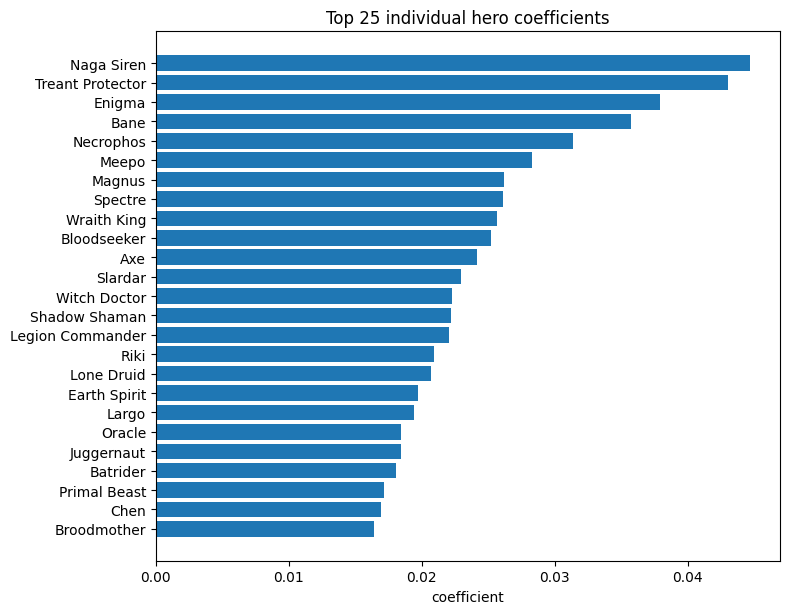

In [39]:
fig, ax = plt.subplots(figsize=(8, max(4, TOP_N * 0.25)))
plot_df = hero_strength_df.head(TOP_N).sort_values("strength_for_side")
ax.barh(plot_df["hero"], plot_df["strength_for_side"])
ax.set_title(f"Top {TOP_N} individual hero coefficients")
ax.set_xlabel("coefficient")
plt.tight_layout()


## Allied Synergies

A synergy coefficient belongs to an unordered allied pair. Positive values mean the pair is good for whichever side drafts both heroes.


In [40]:
synergy_rows = []
for i, hero_a in enumerate(hero_ids):
    for hero_b in hero_ids[i + 1:]:
        first, second = sorted((hero_a, hero_b))
        synergy_rows.append(
            {
                "hero_a": hero_id_to_name[hero_a],
                "hero_b": hero_id_to_name[hero_b],
                "synergy": synergy_weight[first, second].item(),
            }
        )

synergy_df = pd.DataFrame(synergy_rows).sort_values("synergy", ascending=False)
synergy_df.head(TOP_N)


,hero_a,hero_b,synergy
2425,Windranger,Hoodwink,0.054437
2208,Tiny,Monkey King,0.053759
2236,Vengeful Spirit,Sniper,0.052819
6399,Spirit Breaker,Dawnbreaker,0.051621
372,Bane,Muerta,0.050947
5043,Clockwerk,Magnus,0.048578
227,Axe,Techies,0.047873
5216,Nature's Prophet,Void Spirit,0.047657
7573,Bristleback,Earth Spirit,0.047589
4182,Faceless Void,Clockwerk,0.047388


In [41]:
synergy_df.tail(TOP_N).sort_values("synergy")


,hero_a,hero_b,synergy
1642,Pudge,Timbersaw,-0.063060
1150,Morphling,Jakiro,-0.055688
4517,Pugna,Luna,-0.054425
6218,Ancient Apparition,Pangolier,-0.054122
35,Anti-Mage,Beastmaster,-0.053182
7292,Keeper of the Light,Dawnbreaker,-0.051105
7087,Undying,Hoodwink,-0.050281
117,Anti-Mage,Snapfire,-0.048727
2742,Lina,Dawnbreaker,-0.048629
727,Drow Ranger,Dark Willow,-0.048605


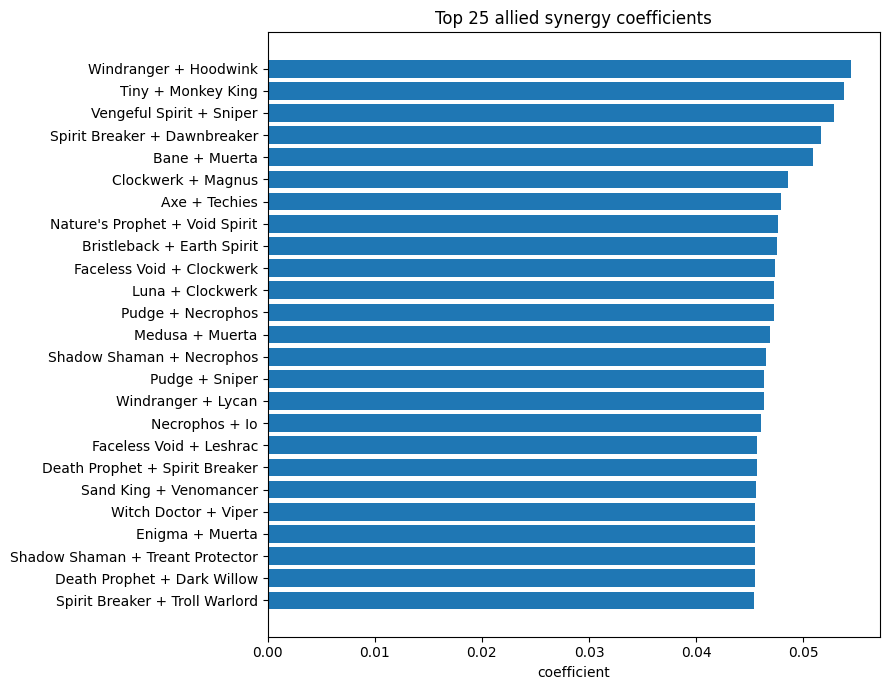

In [42]:
fig, ax = plt.subplots(figsize=(9, max(4, TOP_N * 0.28)))
plot_df = synergy_df.head(TOP_N).copy()
plot_df["pair"] = plot_df["hero_a"] + " + " + plot_df["hero_b"]
plot_df = plot_df.sort_values("synergy")
ax.barh(plot_df["pair"], plot_df["synergy"])
ax.set_title(f"Top {TOP_N} allied synergy coefficients")
ax.set_xlabel("coefficient")
plt.tight_layout()


## Directed Counter-Picks

A counter coefficient is directed: `attacker -> victim`. Positive values mean the attacker is good into the victim for the attacker's side.


In [43]:
counter_rows = []
for attacker_id in hero_ids:
    for victim_id in hero_ids:
        if attacker_id == victim_id:
            continue
        counter_rows.append(
            {
                "attacker": hero_id_to_name[attacker_id],
                "victim": hero_id_to_name[victim_id],
                "counter_score": counter_weight[attacker_id, victim_id].item(),
            }
        )

counter_df = pd.DataFrame(counter_rows).sort_values("counter_score", ascending=False)
counter_df.head(TOP_N)


,attacker,victim,counter_score
136,Axe,Phantom Lancer,0.057626
126,Axe,Anti-Mage,0.057231
11035,Naga Siren,Silencer,0.055974
12122,Timbersaw,Slardar,0.055322
8025,Batrider,Keeper of the Light,0.054018
3220,Shadow Shaman,Alchemist,0.053332
3977,Enigma,Invoker,0.051843
10974,Naga Siren,Puck,0.051692
5352,Phantom Assassin,Weaver,0.051605
11549,Slark,Undying,0.051575


In [44]:
counter_df.tail(TOP_N).sort_values("counter_score")


,attacker,victim,counter_score
1387,Phantom Lancer,Axe,-0.057626
0,Anti-Mage,Axe,-0.057231
9284,Silencer,Naga Siren,-0.055974
3371,Slardar,Timbersaw,-0.055322
11151,Keeper of the Light,Batrider,-0.054018
8971,Alchemist,Shadow Shaman,-0.053332
9103,Invoker,Enigma,-0.051843
1598,Puck,Naga Siren,-0.051692
7728,Weaver,Phantom Assassin,-0.051605
10548,Undying,Slark,-0.051575


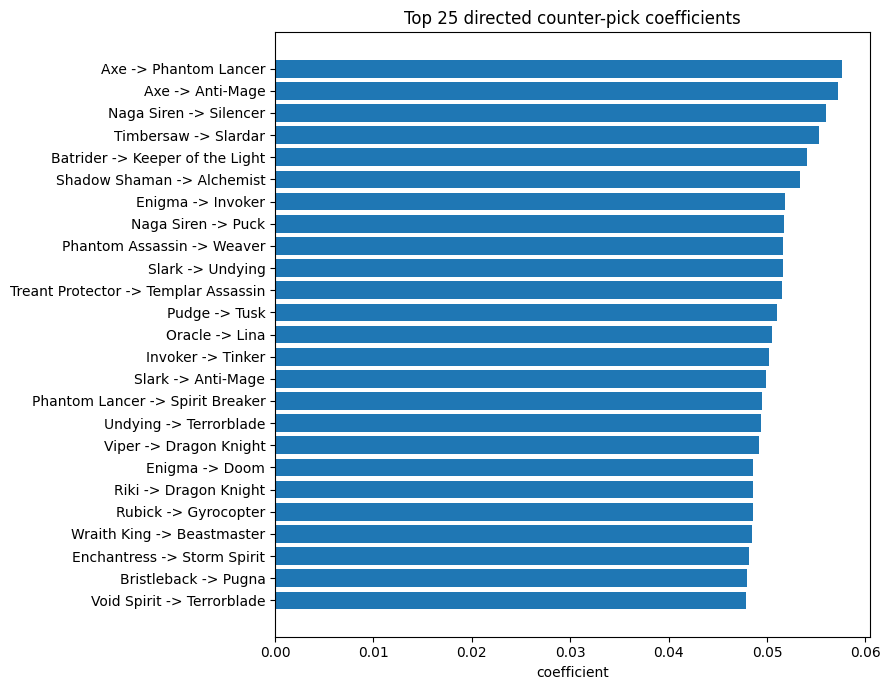

In [45]:
fig, ax = plt.subplots(figsize=(9, max(4, TOP_N * 0.28)))
plot_df = counter_df.head(TOP_N).copy()
plot_df["matchup"] = plot_df["attacker"] + " -> " + plot_df["victim"]
plot_df = plot_df.sort_values("counter_score")
ax.barh(plot_df["matchup"], plot_df["counter_score"])
ax.set_title(f"Top {TOP_N} directed counter-pick coefficients")
ax.set_xlabel("coefficient")
plt.tight_layout()


## Hero Drilldown

Use this helper to inspect one hero: its individual coefficient, strongest allies, heroes it counters, and heroes that counter it.


In [46]:
def hero_report(hero_name, *, top_n=15):
    with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
        hero_id = dataset.hero_name_to_id(hero_name)

    hero = hero_id_to_name[hero_id]
    individual = hero_strength[hero_id].item()

    ally_rows = []
    for other_id in hero_ids:
        if other_id == hero_id:
            continue
        first, second = sorted((hero_id, other_id))
        ally_rows.append(
            {
                "hero": hero_id_to_name[other_id],
                "synergy_with_selected": synergy_weight[first, second].item(),
            }
        )

    counters_rows = []
    countered_by_rows = []
    for other_id in hero_ids:
        if other_id == hero_id:
            continue
        counters_rows.append(
            {
                "victim": hero_id_to_name[other_id],
                "selected_counters_victim": counter_weight[hero_id, other_id].item(),
            }
        )
        countered_by_rows.append(
            {
                "attacker": hero_id_to_name[other_id],
                "attacker_counters_selected": counter_weight[other_id, hero_id].item(),
            }
        )

    return {
        "hero": hero,
        "individual_strength": individual,
        "best_allies": pd.DataFrame(ally_rows).sort_values("synergy_with_selected", ascending=False).head(top_n),
        "best_victims": pd.DataFrame(counters_rows).sort_values("selected_counters_victim", ascending=False).head(top_n),
        "worst_threats": pd.DataFrame(countered_by_rows).sort_values("attacker_counters_selected", ascending=False).head(top_n),
    }

report = hero_report("anti mage", top_n=TOP_N)
report["hero"], report["individual_strength"]


('Anti-Mage', -0.032723456621170044)

In [47]:
report["best_allies"]


,hero,synergy_with_selected
79,Meepo,0.038497
107,Phoenix,0.028526
74,Lycan,0.027764
27,Witch Doctor,0.026135
19,Windranger,0.024905
39,Wraith King,0.024006
30,Enigma,0.022803
66,Doom,0.022175
99,Abaddon,0.021250
69,Gyrocopter,0.020824


In [48]:
report["best_victims"]


,victim,selected_counters_victim
91,Medusa,0.041995
87,Keeper of the Light,0.040388
96,Bristleback,0.035860
26,Tidehunter,0.033363
8,Morphling,0.031815
89,Visage,0.030203
123,Muerta,0.025684
119,Ring Master,0.024953
98,Skywrath Mage,0.023785
17,Tiny,0.019706


In [49]:
report["worst_threats"]


,attacker,attacker_counters_selected
0,Axe,0.057231
90,Slark,0.049919
102,Techies,0.046407
85,Nyx Assassin,0.039345
86,Naga Siren,0.035515
104,Earth Spirit,0.034178
113,Pangolier,0.034013
125,Largo,0.033967
14,Sand King,0.033529
24,Shadow Shaman,0.033357


## Draft Explanation

The helper below decomposes one custom draft into hero, synergy, and counter contributions.


In [50]:
def explain_draft(radiant_hero_names, dire_hero_names):
    if len(radiant_hero_names) != 5 or len(dire_hero_names) != 5:
        raise ValueError("Both teams must contain exactly five heroes.")

    with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
        radiant = [dataset.hero_name_to_id(hero) for hero in radiant_hero_names]
        dire = [dataset.hero_name_to_id(hero) for hero in dire_hero_names]

    radiant_tensor = torch.tensor([radiant], dtype=torch.long, device=device)
    dire_tensor = torch.tensor([dire], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        logit = model(radiant_tensor, dire_tensor).cpu().item()
    dire_probability = 1 / (1 + np.exp(-logit))

    rows = []
    for side_name, sign, team in [("radiant", -1, radiant), ("dire", 1, dire)]:
        for hero_id in team:
            rows.append({"group": "hero", "side": side_name, "term": hero_id_to_name[hero_id], "contribution_to_dire_logit": sign * hero_strength[hero_id].item()})

        for i, hero_a in enumerate(team):
            for hero_b in team[i + 1:]:
                first, second = sorted((hero_a, hero_b))
                rows.append({"group": "synergy", "side": side_name, "term": f"{hero_id_to_name[hero_a]} + {hero_id_to_name[hero_b]}", "contribution_to_dire_logit": sign * synergy_weight[first, second].item()})

    for attacker_side, sign, attackers, victims in [
        ("dire", 1, dire, radiant),
        ("radiant", -1, radiant, dire),
    ]:
        for attacker in attackers:
            for victim in victims:
                rows.append({"group": "counter", "side": attacker_side, "term": f"{hero_id_to_name[attacker]} -> {hero_id_to_name[victim]}", "contribution_to_dire_logit": sign * counter_weight[attacker, victim].item()})

    contribution_df = pd.DataFrame(rows).sort_values("contribution_to_dire_logit", ascending=False)
    return {
        "radiant_win_probability": 1 - dire_probability,
        "dire_win_probability": dire_probability,
        "predicted_winner": "dire" if dire_probability >= THRESHOLD else "radiant",
        "logit": logit,
        "contributions": contribution_df,
    }

example = explain_draft(
    radiant_hero_names=["anti mage", "crystal maiden", "axe", "puck", "lich"],
    dire_hero_names=["juggernaut", "shadow fiend", "lion", "centaur warrunner", "witch doctor"],
)
{key: value for key, value in example.items() if key != "contributions"}


{'radiant_win_probability': 0.3877473531113027,
 'dire_win_probability': 0.6122526468886973,
 'predicted_winner': 'dire',
 'logit': 0.4567910432815552}

In [51]:
example["contributions"].head(20)


,group,side,term,contribution_to_dire_logit
8,synergy,radiant,Anti-Mage + Lich,0.037454
52,counter,dire,Witch Doctor -> Axe,0.034434
69,counter,radiant,Axe -> Witch Doctor,0.034434
0,hero,radiant,Anti-Mage,0.032723
3,hero,radiant,Puck,0.031705
10,synergy,radiant,Crystal Maiden + Puck,0.030345
61,counter,radiant,Crystal Maiden -> Shadow Fiend,0.025142
36,counter,dire,Shadow Fiend -> Crystal Maiden,0.025142
46,counter,dire,Centaur Warrunner -> Crystal Maiden,0.022978
63,counter,radiant,Crystal Maiden -> Centaur Warrunner,0.022978


In [52]:
example["contributions"].tail(20).sort_values("contribution_to_dire_logit")


,group,side,term,contribution_to_dire_logit
9,synergy,radiant,Crystal Maiden + Axe,-0.026154
28,synergy,dire,Lion + Witch Doctor,-0.025032
2,hero,radiant,Axe,-0.024158
74,counter,radiant,Puck -> Witch Doctor,-0.019113
53,counter,dire,Witch Doctor -> Puck,-0.019113
26,synergy,dire,Shadow Fiend + Witch Doctor,-0.017392
40,counter,dire,Lion -> Anti-Mage,-0.012357
57,counter,radiant,Anti-Mage -> Lion,-0.012357
76,counter,radiant,Lich -> Shadow Fiend,-0.010961
39,counter,dire,Shadow Fiend -> Lich,-0.010961
